Successfully loaded simulation data from Q_simulated_all_scenarios.csv


c:\Users\hdagne1\AppData\Local\miniforge3\envs\mosart-dev\lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\hdagne1\AppData\Local\miniforge3\envs\mosart-dev\lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


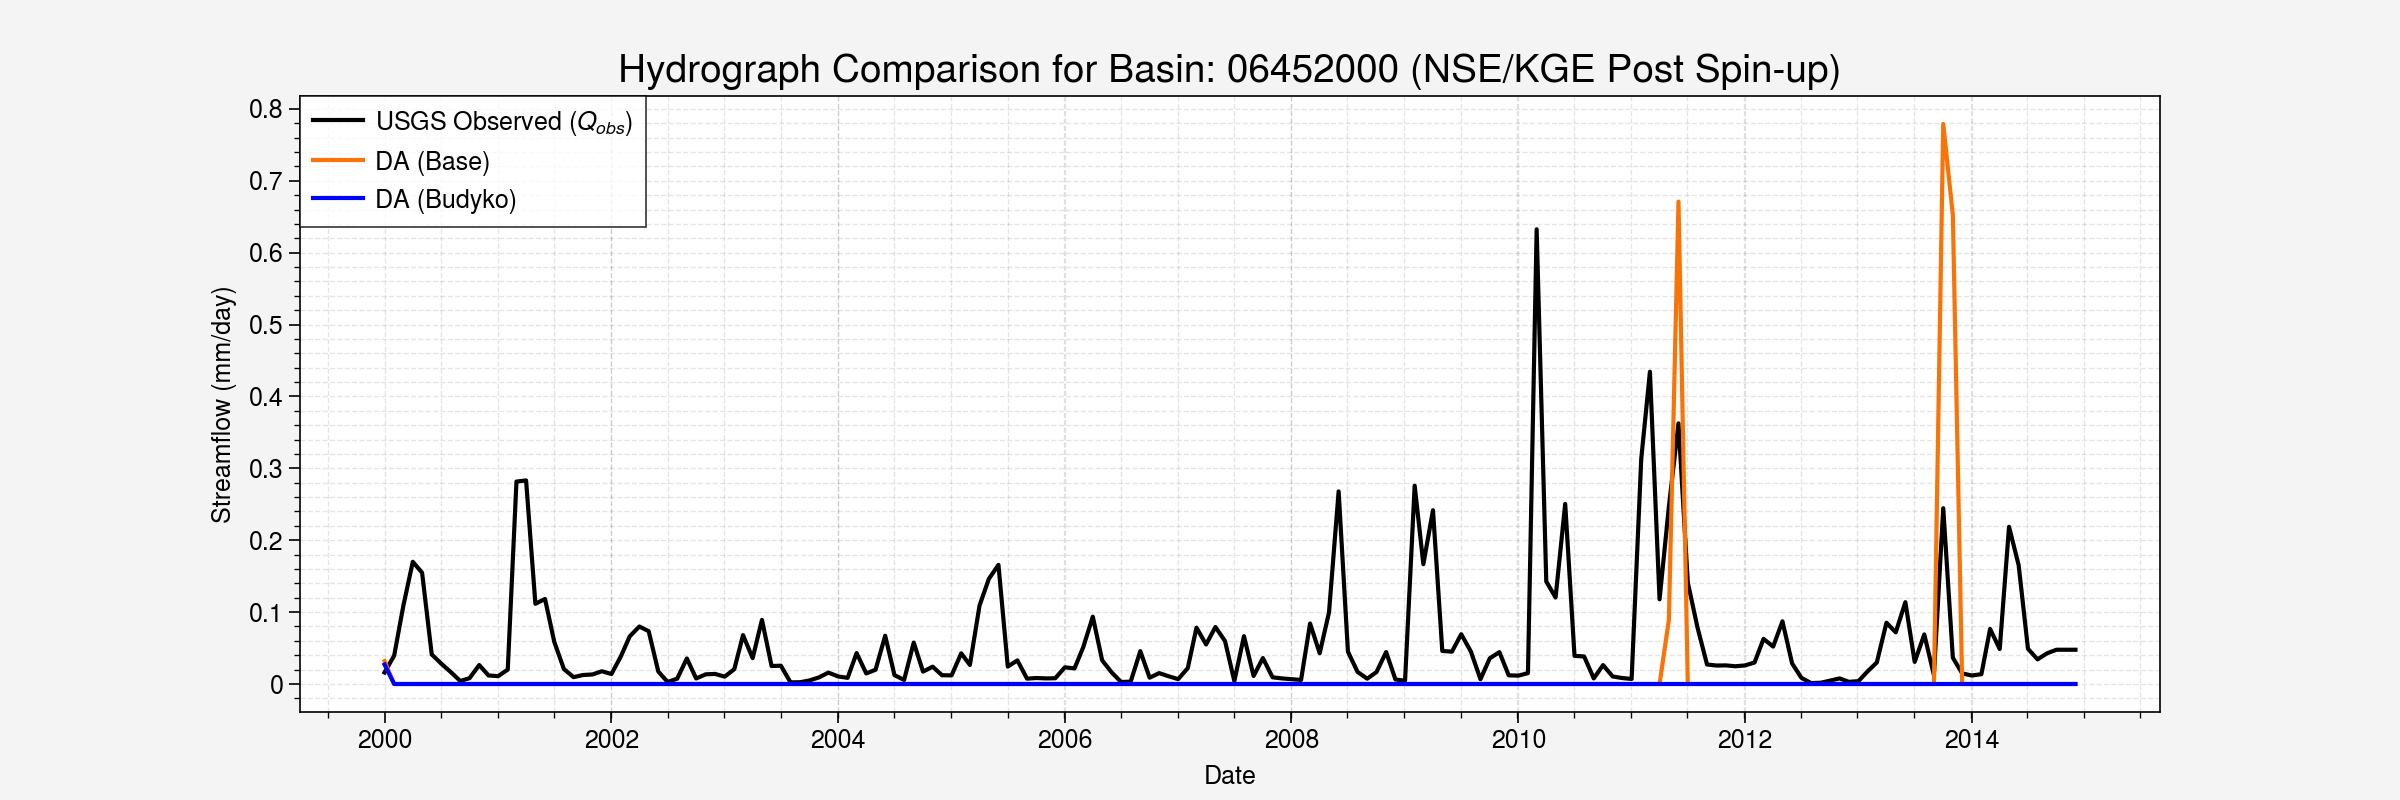

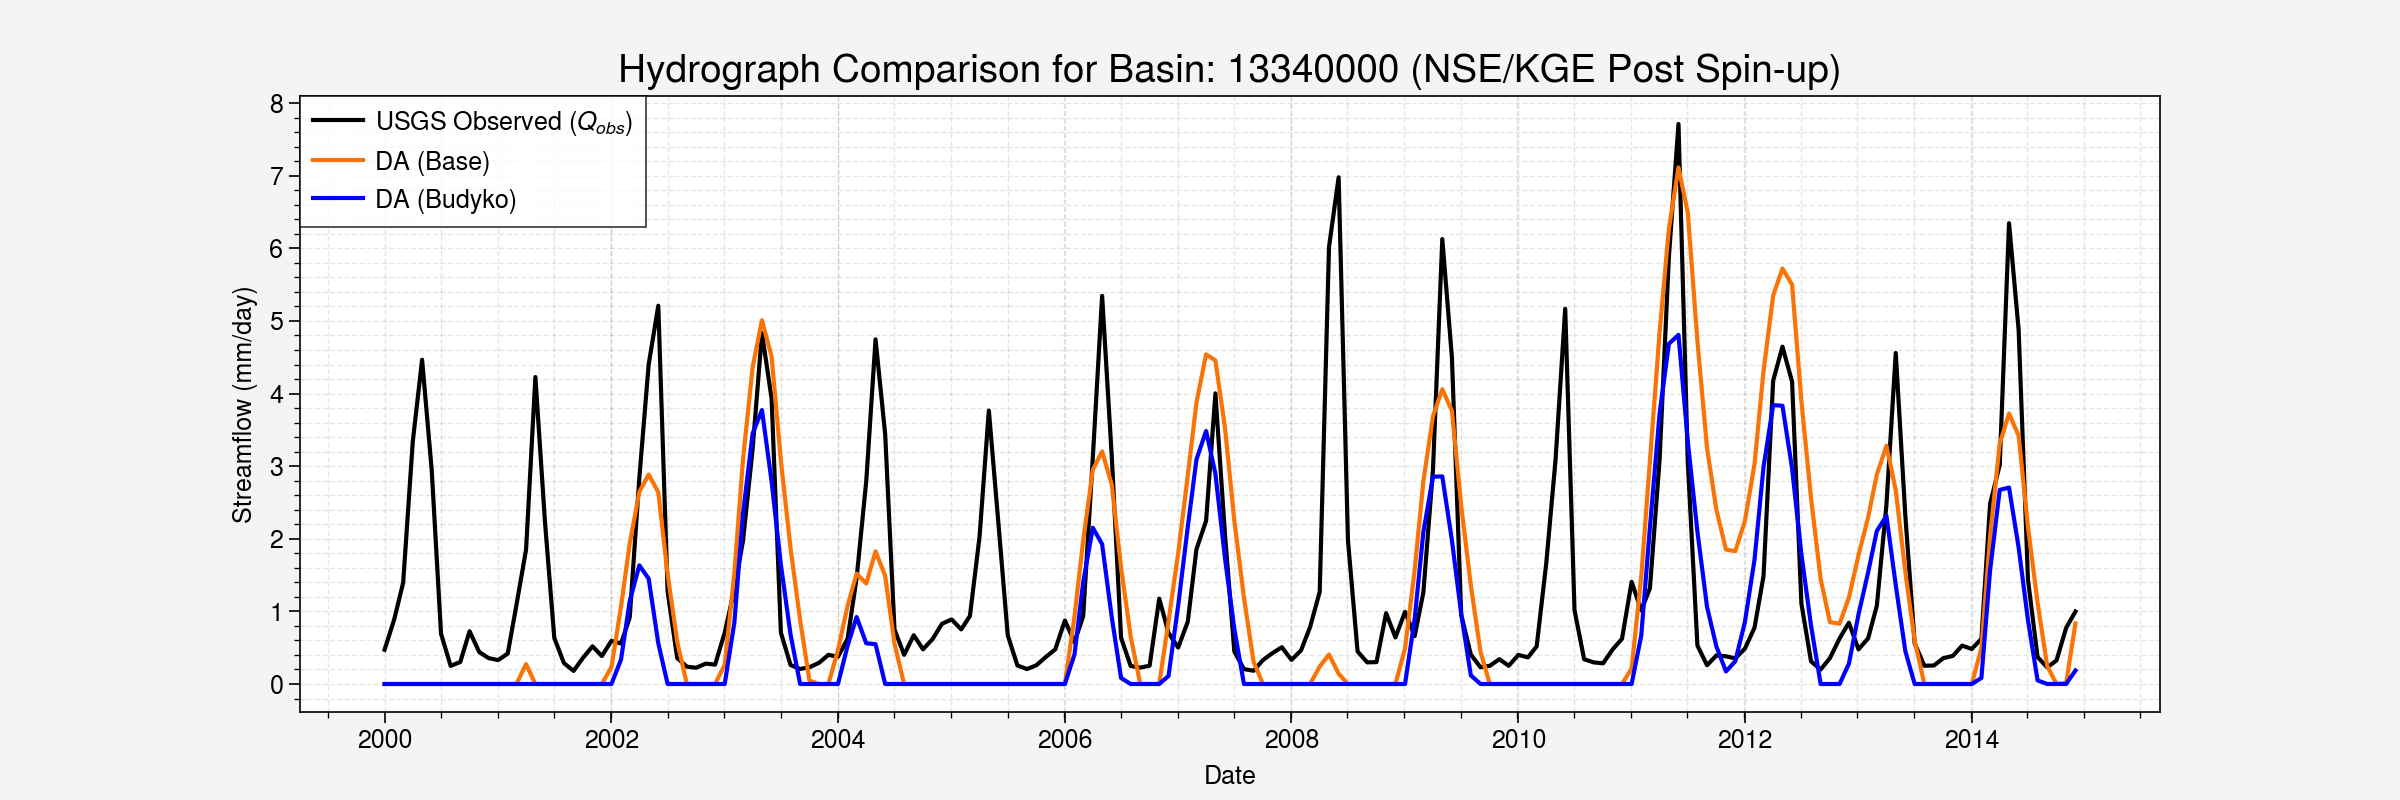

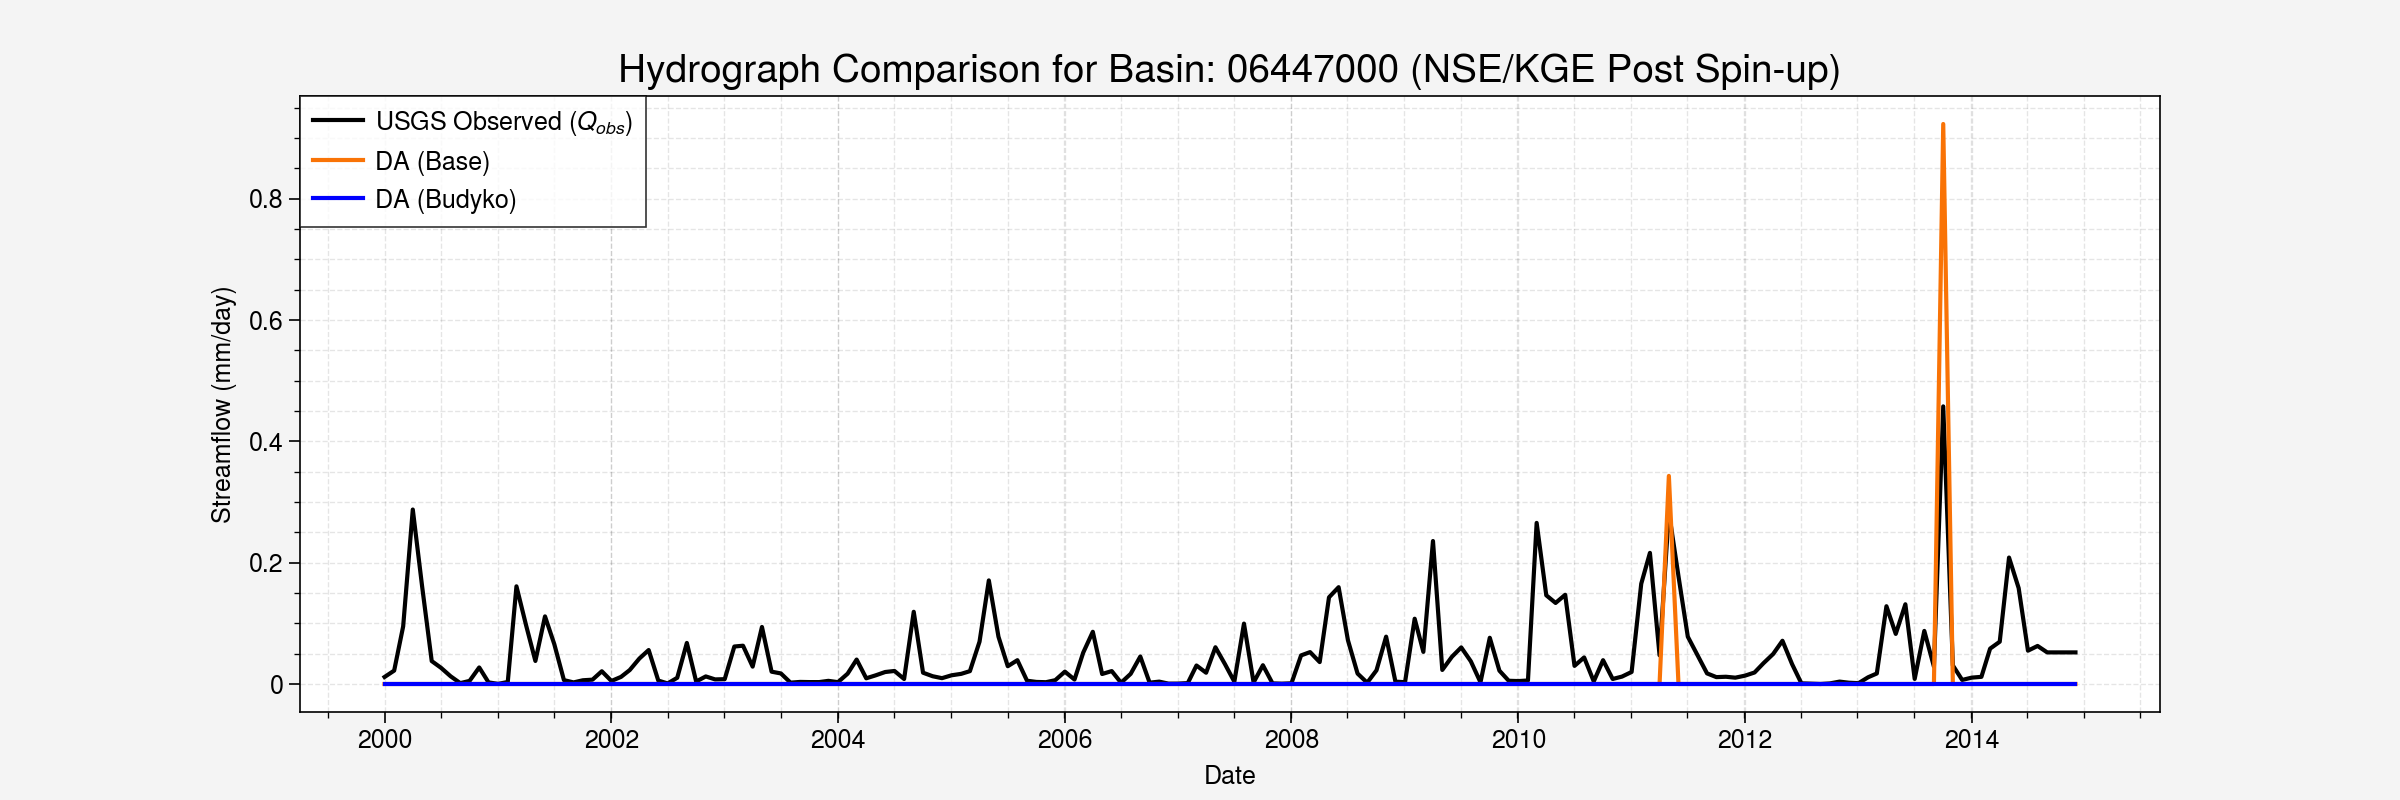

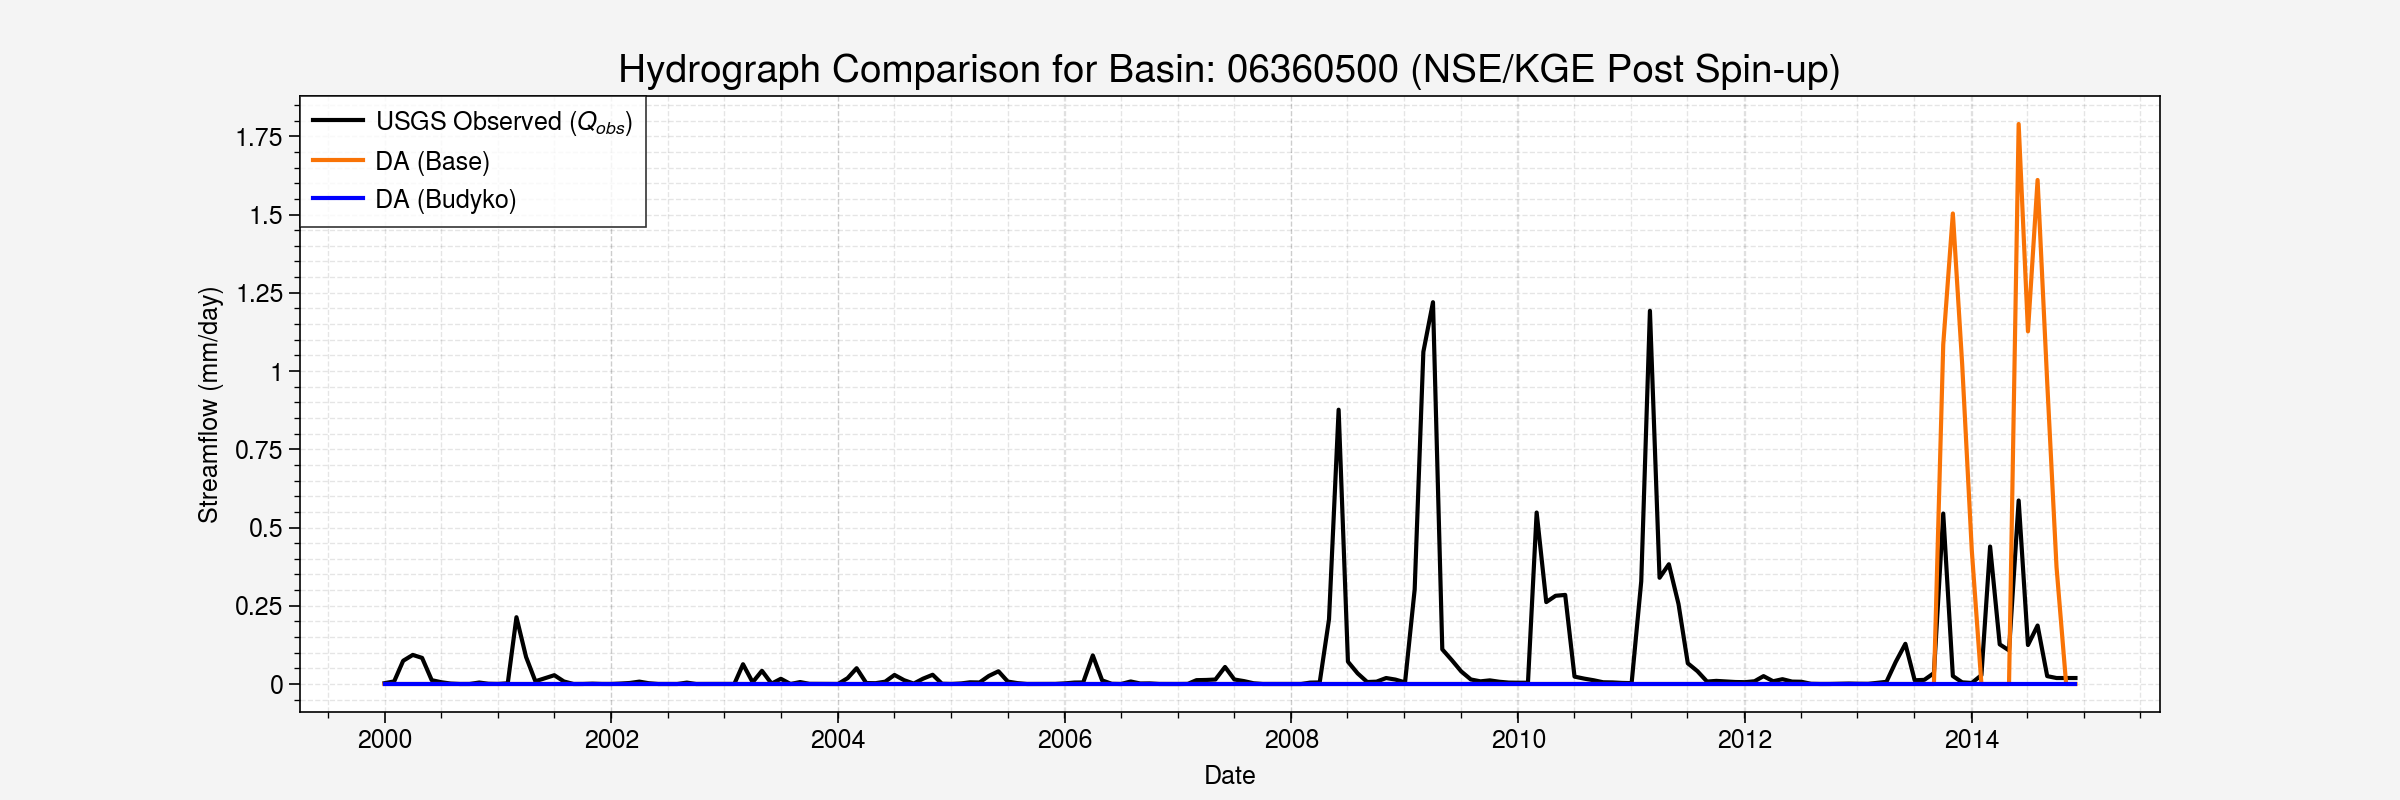

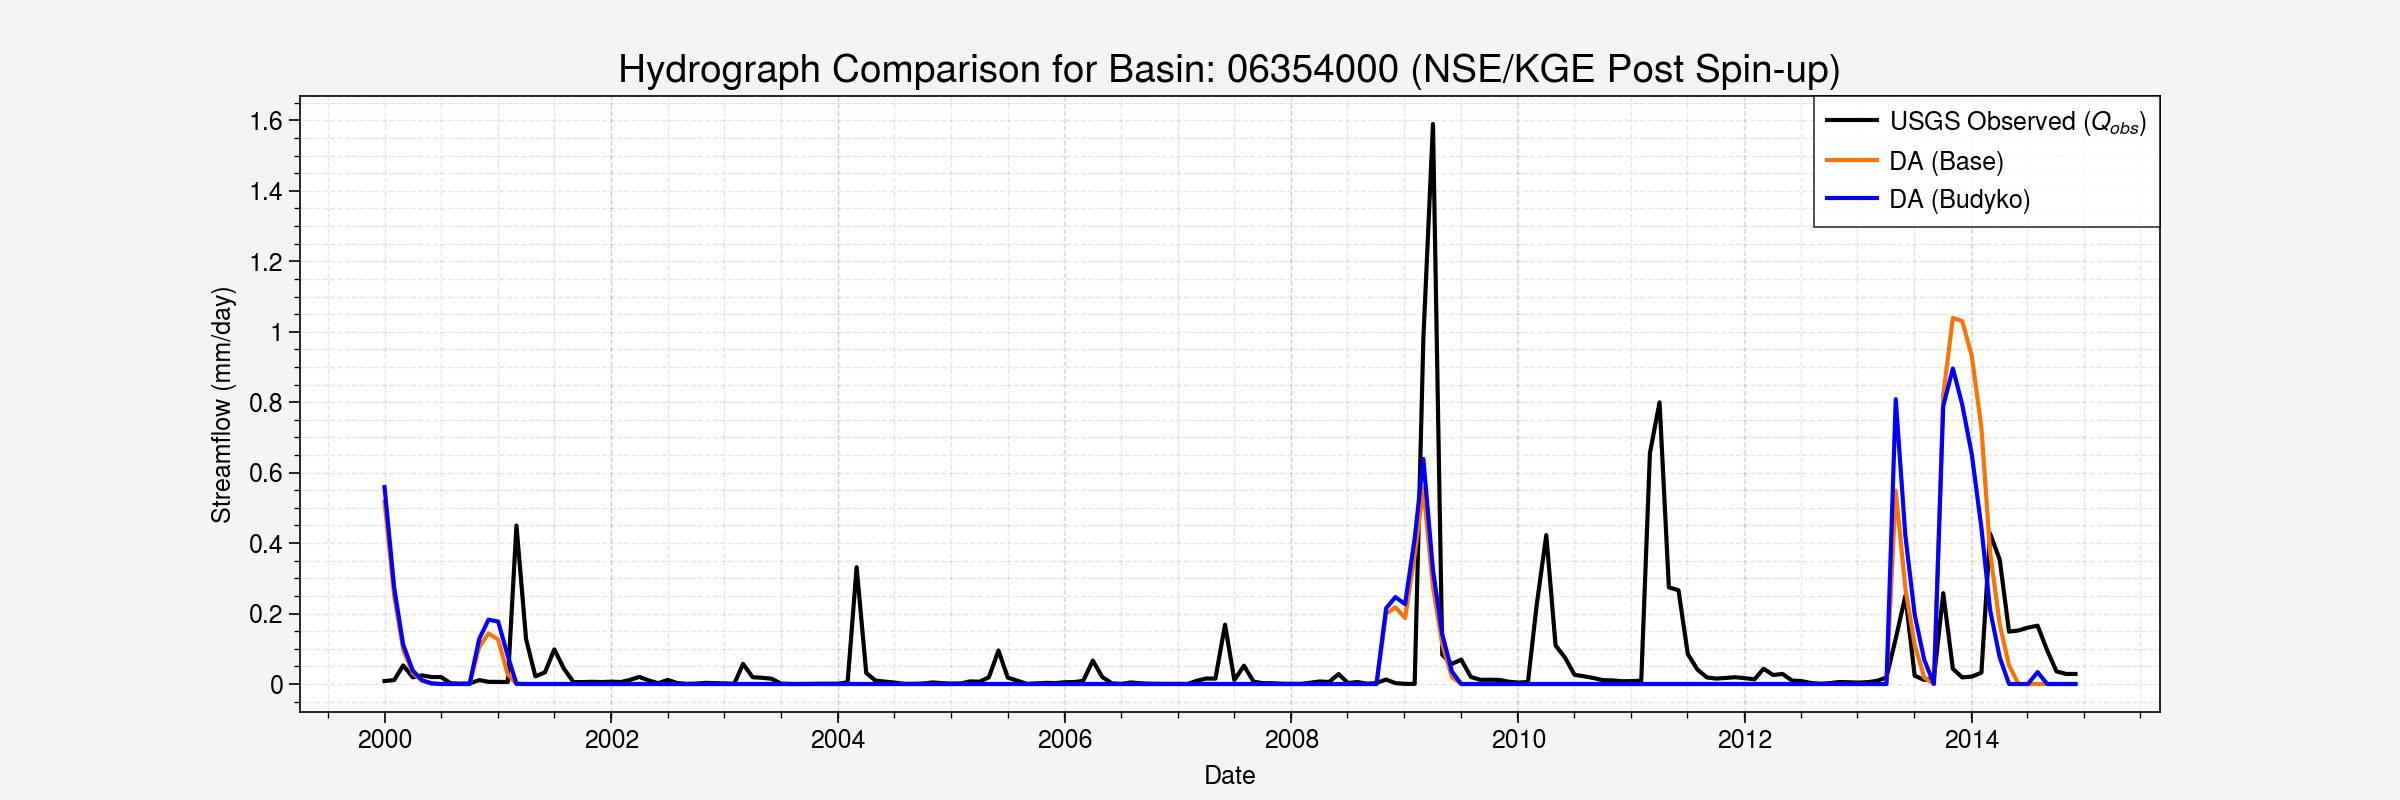

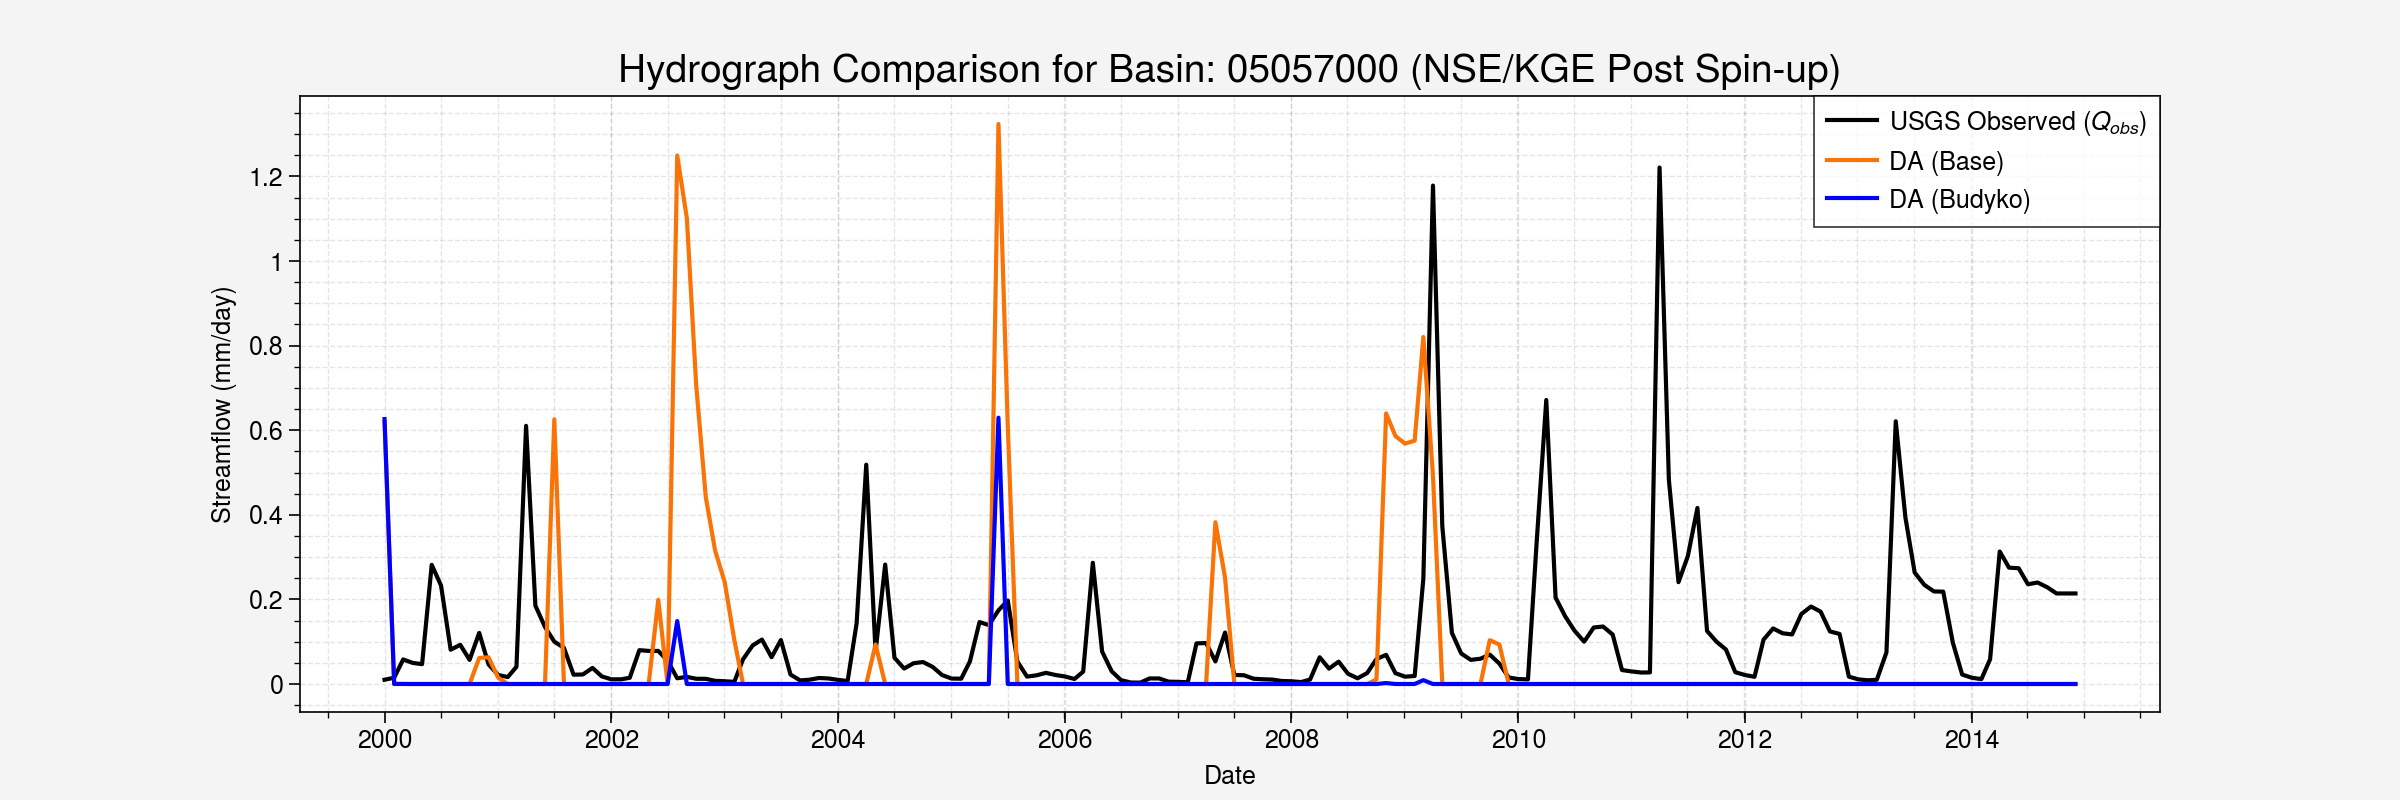

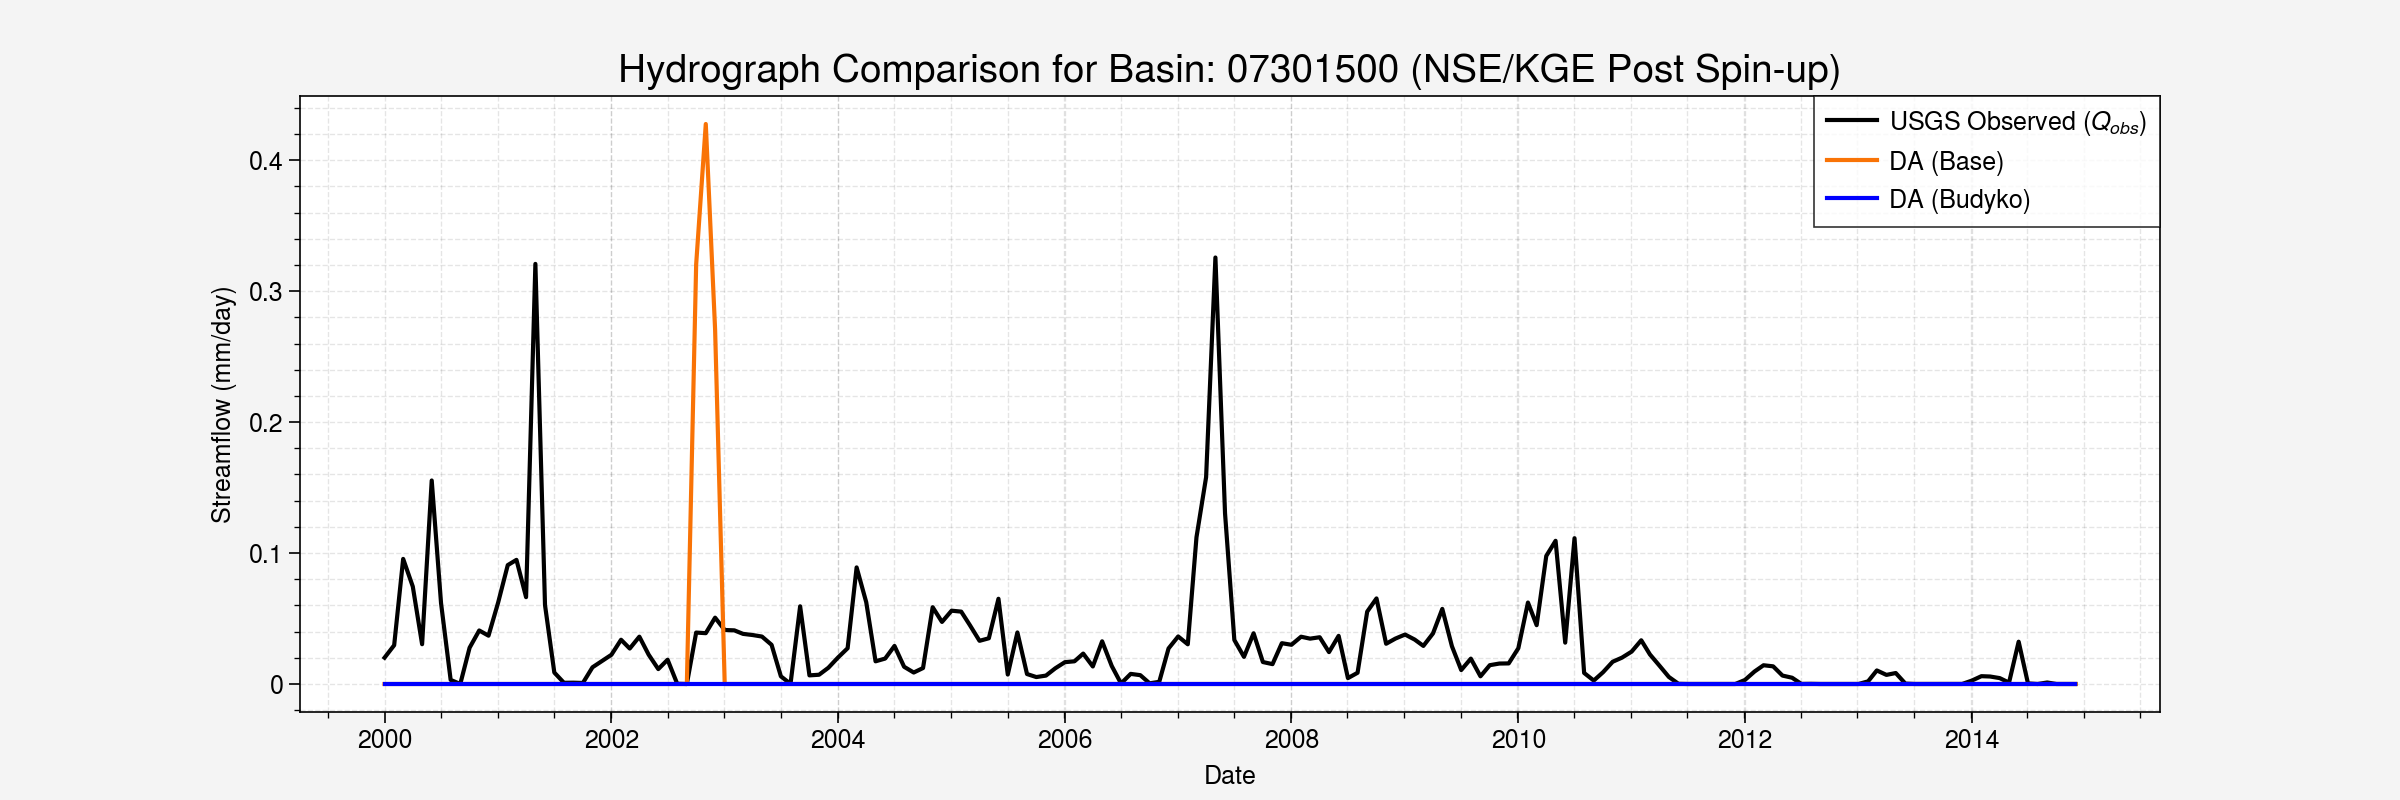

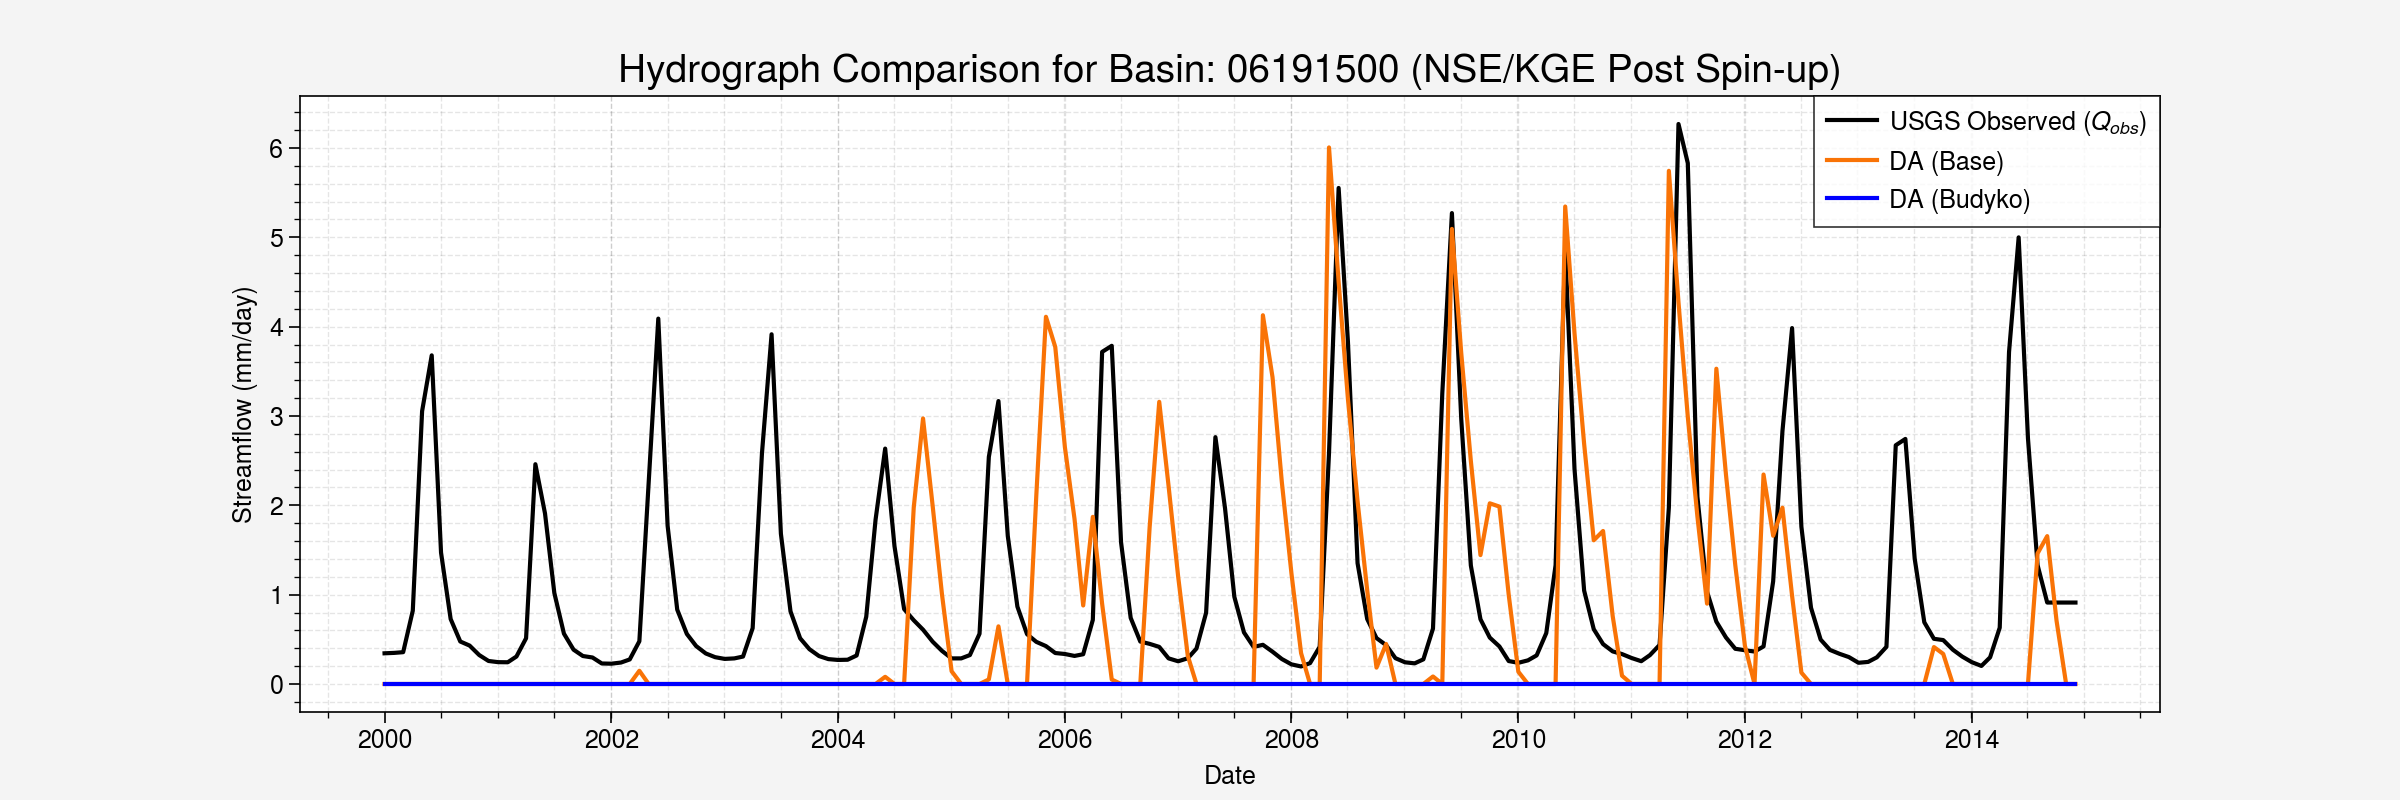

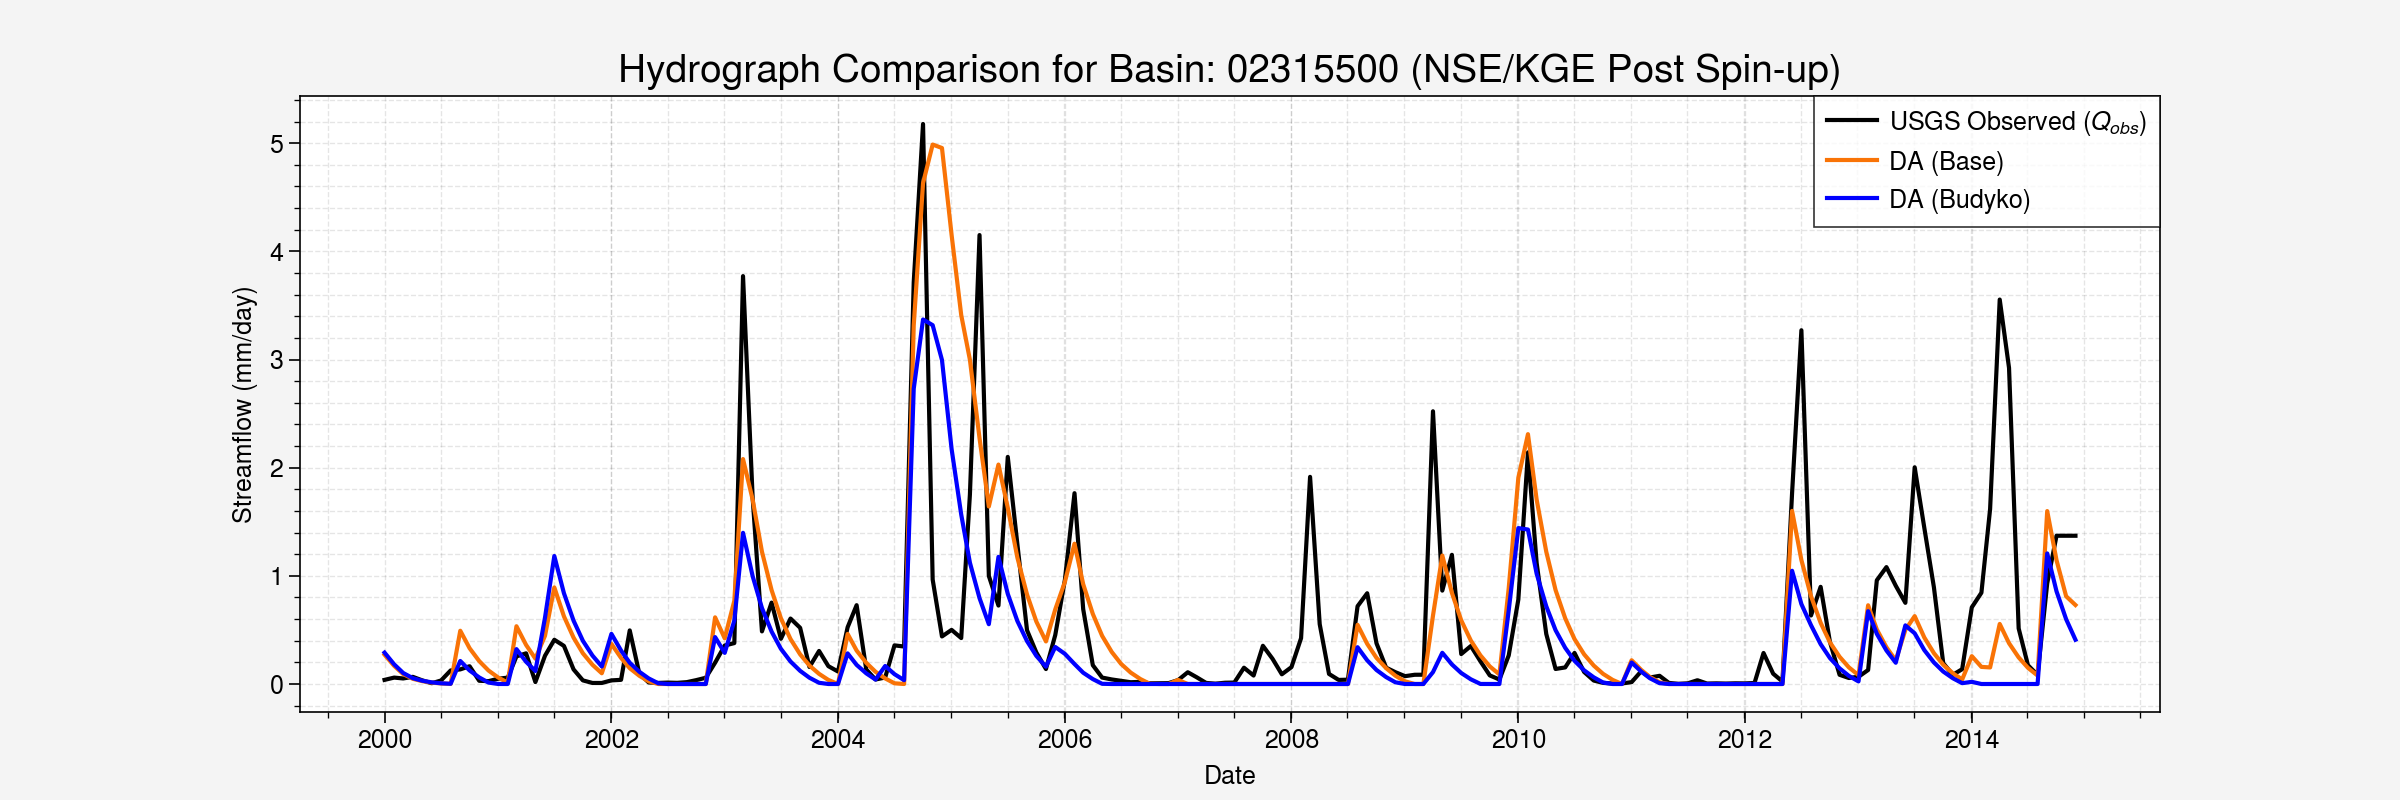

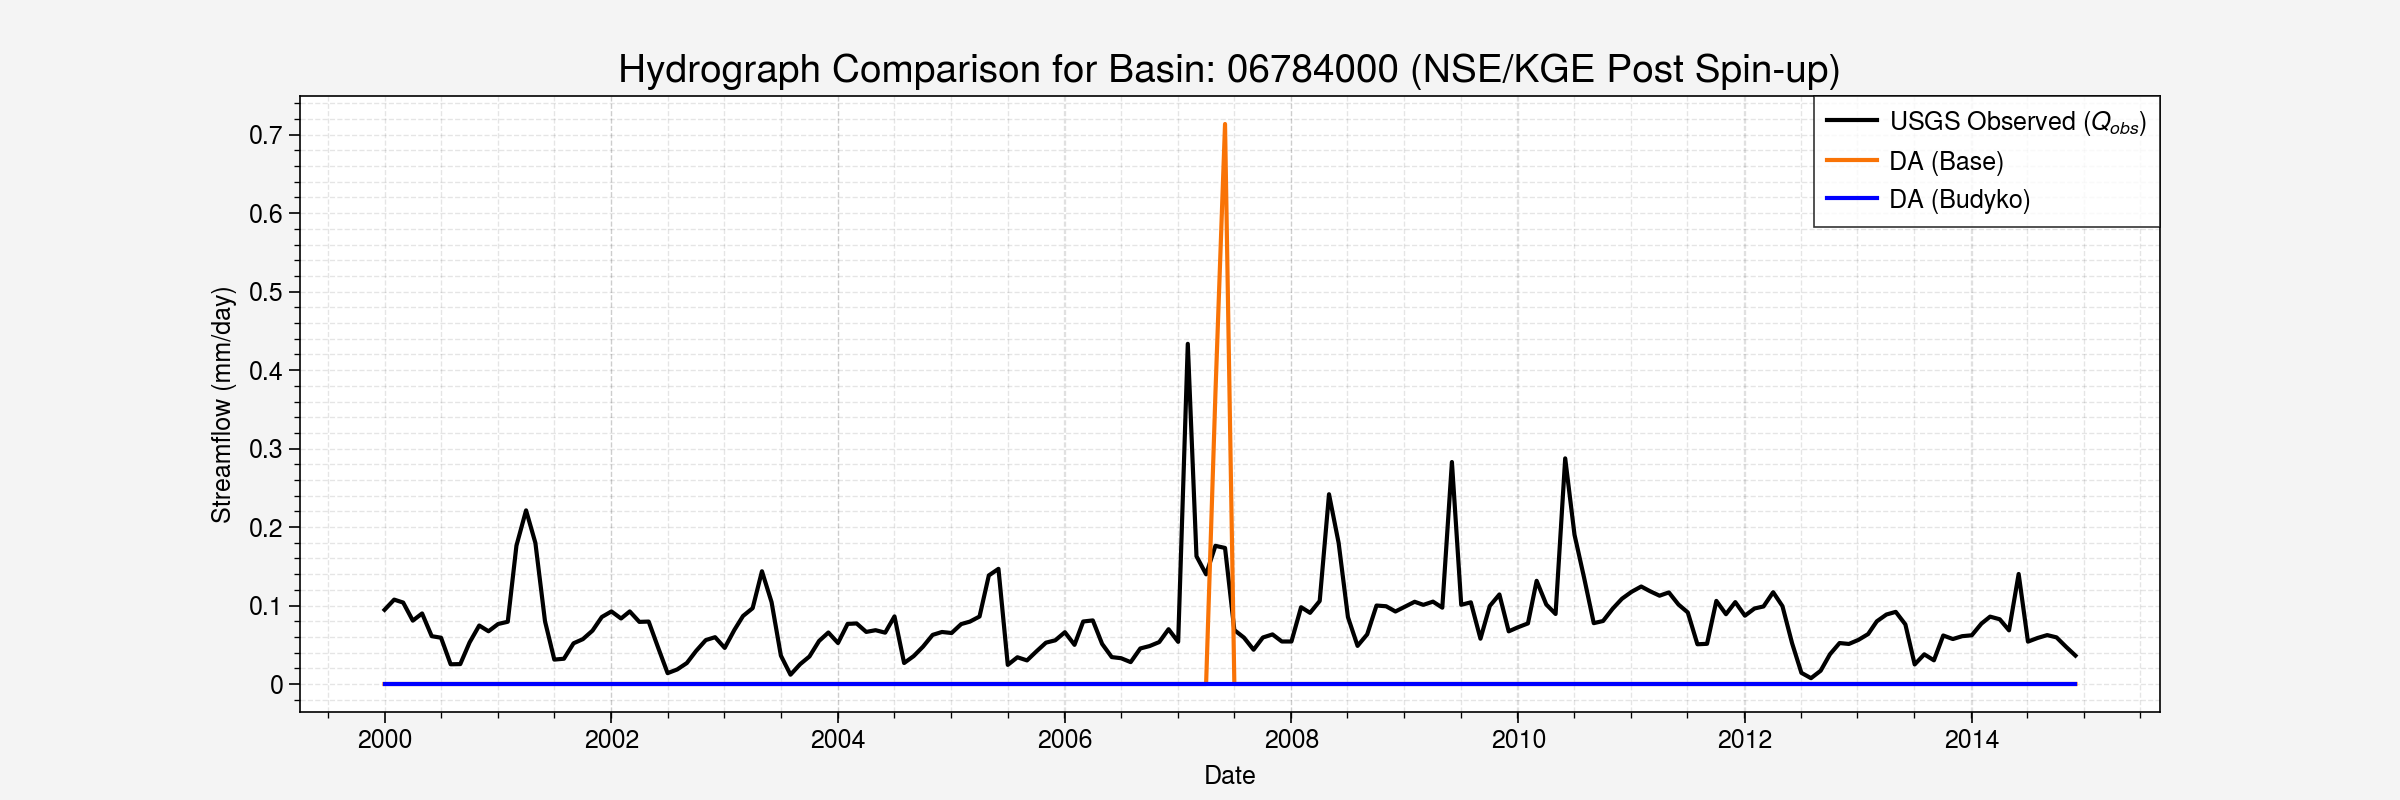

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

# 1. Setup Path (Assuming you need to access 'src/metrics.py' or data paths)
# Navigate up from Notebook to the project root: .../Bayesian_DA_Budyko_modeling/
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(PROJECT_ROOT)

# Import metrics function (assuming it's in src/metrics.py)
from src.metrics import calculate_nse, calculate_kge

# --- Configuration (Adjust file paths based on where run_simulation.py saves data) ---

# Define the folder where your results (e.g., Q_simulated_df) are saved.
# Assuming results are saved in a 'results' folder at the project root.
RESULTS_FOLDER = os.path.join(PROJECT_ROOT, 'results')

# Define the filename for the saved simulated flow data.
# You MUST check your run_simulation.py script to see what it saved!
SIMULATED_Q_FILE = 'Q_simulated_all_scenarios.csv' 
OBSERVED_Q_FILE = 'Q_observed_usgs.csv' 
SPIN_UP_YEARS = 5
SPIN_UP_MONTHS = SPIN_UP_YEARS * 12

# --- 2. Load Data ---

try:
    # Load the combined simulation results (Q_simulated)
    Q_sim_df = pd.read_csv(os.path.join(RESULTS_FOLDER, SIMULATED_Q_FILE), index_col=0, parse_dates=True)
    
    # Load the original observed streamflow (Q_usgs)
    Q_obs_df = pd.read_csv(os.path.join(RESULTS_FOLDER, OBSERVED_Q_FILE), index_col=0, parse_dates=True)
    
    # The 'run_simulation.py' output showed a summary table, but we need the raw time series
    print(f"Successfully loaded simulation data from {SIMULATED_Q_FILE}")

except FileNotFoundError:
    print(f"FATAL: Could not find results files in {RESULTS_FOLDER}.")
    print("Please check the 'RESULTS_FOLDER' and file names.")
    # Exit or create empty dataframes to prevent further errors
    Q_sim_df = None
    Q_obs_df = None

if Q_sim_df is not None:
    
    # Identify the basins and scenarios
    BASIN_IDS = Q_obs_df.columns.tolist()
    SCENARIOS = ['Q_ke', 'Q_assim_base', 'Q_assim_Budyko']
    
    # --- 3. Re-calculate and Summarize Metrics (Post Spin-up) ---

    summary_metrics = {'Basin': BASIN_IDS}
    
    # Ensure the DataFrames are aligned by time (index) and cut off spin-up
    Q_obs_post_spinup = Q_obs_df.iloc[SPIN_UP_MONTHS:]
    Q_sim_post_spinup = Q_sim_df.iloc[SPIN_UP_MONTHS:]

    for scenario in SCENARIOS:
        nse_list = []
        kge_list = []
        
        for basin in BASIN_IDS:
            # Simulated data columns are named like '06452000_Q_ke'
            sim_col = f"{basin}_{scenario}" 
            
            # Extract the correct time series
            Q_sim = Q_sim_post_spinup[sim_col].values
            Q_obs = Q_obs_post_spinup[basin].values
            
            # Calculate metrics
            nse_list.append(calculate_nse(Q_obs, Q_sim))
            kge_list.append(calculate_kge(Q_obs, Q_sim))

        summary_metrics[f'{scenario}_NSE'] = nse_list
        summary_metrics[f'{scenario}_KGE'] = kge_list

    metrics_df = pd.DataFrame(summary_metrics).set_index('Basin')
    
    # print("\n--- Summary Performance (Recalculated) ---")
    # print(metrics_df)

    # --- 4. Visualization (Hydrographs) ---

    # Select one or two basins for detailed visualization
    # PLOT_BASINS = ['06452000', '02315500'] # One bad, one better (from previous output)
    PLOT_BASINS = ['06452000', '13340000', '06447000', '06360500', '06354000', '05057000','07301500', '06191500', '02315500', '06784000']

    for basin_id in PLOT_BASINS:
        plt.figure(figsize=(12, 4))
        
        # # Observed Flow
        plt.plot(Q_obs_df.index, Q_obs_df[basin_id], label='USGS Observed ($Q_{obs}$)', color='black', linewidth=1.5)
        
        # Base Model (Q_ke)
        # plt.plot(Q_sim_df.index, Q_sim_df[f'{basin_id}_Q_ke'], label='Base Model ($Q_{ke}$)', color='grey', linestyle='--')
        
        # Assimilated Model - Base Parameters
        plt.plot(Q_sim_df.index, Q_sim_df[f'{basin_id}_Q_assim_base'], label='DA (Base)', color='orange')
        
        # # Assimilated Model - Budyko Parameters
        plt.plot(Q_sim_df.index, Q_sim_df[f'{basin_id}_Q_assim_Budyko'], label='DA (Budyko)', color='blue')
        
        # # Add spin-up line
        # plt.axvline(Q_obs_df.index[SPIN_UP_MONTHS], color='red', linestyle=':', label='End of Spin-up')
        
        plt.title(f'Hydrograph Comparison for Basin: {basin_id} (NSE/KGE Post Spin-up)', fontsize=14)
        plt.xlabel('Date')
        plt.ylabel('Streamflow (mm/day)')
        plt.legend()
        plt.grid(True, which='both', linestyle='--', linewidth=0.5)
        plt.show()

In [65]:
sceua_cal_02315500 = pd.read_csv(r'C:\Users\hdagne1\Box\Dr.Mesfin Research\Codes\DA\DA_Github_repo\Bayesian_DA_Budyko_modeling\SCE_UA_Results\sceua_cal_02315500.csv') 

In [69]:
sceua_cal_02315500.columns

Index(['like1', 'parKperc', 'parKb', 'parKe', 'parCqq', 'parBias', 'chain'], dtype='object')